# Masking-strategy faithfulness — insertion / deletion benchmark

Which *removal function* yields the most faithful explanation? Every panel below
answers that for one masking strategy, on ImageNet, across three model families.

**Method.** For each model × image × masking strategy:

1. Split the image into ~25 SLIC superpixels (the players).
2. Compute order-1 Shapley values with that strategy as the imputer's removal rule
   (`shapiq` KernelSHAP, fixed budget).
3. Rank superpixels by attribution, then measure `P(target)` while **inserting** them
   best-first, and while **deleting** them best-first, against a *fixed* neutral gray
   baseline.
4. `ABC = AUC(insertion) − AUC(deletion)`. Higher = more faithful.

Only the attribution-producing strategy varies; the curves themselves always use the
same fixed baseline and the same scoring, so ABC is comparable across strategies even
though the underlying games are not (see the note on token masking below).

A **random** attribution order is the floor: it should score ≈ 0.

This notebook is self-contained — it needs only `shapiq` (branch `feature/pr_final`),
`torch`, `torchvision`, `transformers`, `datasets`, and `scikit-image`.


## 1 · Config

`PILOT = True` runs a few images end-to-end in a couple of minutes. Set it to `False`
for the full run (~4.5 h on a GPU).

A **run** is a model plus a partition. Three of them:

| run | model | partition | why |
|---|---|---|---|
| `resnet50` | ResNet-50 | 25 SLIC superpixels | the CNN reference |
| `vit` | ViT-B/16 | 25 SLIC superpixels | ViT on the same footing as the CNN |
| `vit_grid49` | ViT-B/16 | 49 uniform tiles | **fair** comparison for token masking |

The third run exists because `attention` (token masking) *cannot* use SLIC superpixels —
`PatchStrategy` has to tile ViT's 14×14 token grid, so it only supports 4, 49 or 196
players. Comparing it against SLIC-based strategies confounds the removal rule with the
partition. `GridStrategy(grid_shape=7)` produces 49 tiles of 32×32 px, geometrically
**identical** to `PatchStrategy(grid_size=14, n_players=49)`, so in `vit_grid49` every
panel shares one partition and only the removal rule varies.


In [1]:
PILOT = False               # True = quick smoke test on a few images

N_TEST = 20 if PILOT else 1000      # correctly-classified images scored per run
N_BACKGROUND = 20 if PILOT else 100 # reference bank for MarginalSampling (disjoint)
N_SUPERPIXELS = 25                  # SLIC players for the superpixel runs
TOKEN_PLAYERS = 49                  # 7x7 blocks of ViT-B/16's 14x14 token grid
BUDGET = 384                        # coalitions per explanation
BASELINE = 0.5                      # gray fill used by the insertion/deletion curves
AMP = True                          # bfloat16 autocast for forwards

# (run name, model, partition). "grid49" is geometrically identical to the token grid.
RUNS = [
    ("resnet50", "resnet50", "slic25"),
    ("vit", "vit", "slic25"),
    ("vit_grid49", "vit", "grid49"),
]

# "attention" is the token-space strategy; ViT-only, added automatically.
METHODS = ["meancolor", "zero", "datasetmean", "blur", "marginal", "inpainting"]

# Pilot runs write to their own files so a smoke test can never clobber a real run.
SUFFIX = ".pilot" if PILOT else ""
OUT_JSON = f"data/faithfulness_results{SUFFIX}.json"
OUT_NPZ = f"data/faithfulness_results{SUFFIX}.npz"

# Skip runs already complete in OUT_JSON. The full sweep takes hours, so it must be
# restartable; set False to force everything to recompute.
RESUME = True

## 2 · Setup

In [2]:
from __future__ import annotations

import contextlib
import json
import time

import numpy as np
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

if DEVICE == "cuda":  # input size is fixed at 224, so autotune pays off
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


def autocast():
    if AMP and DEVICE == "cuda":
        return torch.autocast("cuda", dtype=torch.bfloat16)
    return contextlib.nullcontext()


print("device:", DEVICE)
print("torch :", torch.__version__)
import shapiq

print("shapiq:", shapiq.__version__)

device: cuda
torch : 2.9.1+cu130


shapiq: 1.6.1.dev42+gb75fc72f8.d20260716


## 3 · Data

ImageNet-val streamed from the Hub. The background bank for `MarginalSampling` uses a
different seed than the test pool, so the two are disjoint.


In [3]:
def load_images(n_total: int, size: int = 224, seed: int = 0):
    """Stream n_total ImageNet-val images as (H, W, 3) uint8 arrays + int labels."""
    from datasets import load_dataset

    ds = load_dataset("benjamin-paine/imagenet-1k-256x256", split="validation", streaming=True)
    ds = ds.shuffle(seed=seed, buffer_size=2000)
    images, labels = [], []
    for example in ds:
        image = example["image"].convert("RGB").resize((size, size))
        images.append(np.asarray(image, dtype=np.uint8))
        labels.append(int(example["label"]))
        if len(images) >= n_total:
            break
    return images, labels


background_images, _ = load_images(N_BACKGROUND, seed=123)
background_bank = torch.stack(
    [torch.from_numpy(im).permute(2, 0, 1).float() / 255.0 for im in background_images]
)
pool, pool_labels = load_images(N_TEST * 2 + 50, seed=7)
print(f"background bank: {tuple(background_bank.shape)} | test pool: {len(pool)} images")

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

C:\Users\iphon\AppData\Local\Temp\ipykernel_4488\326123230.py:19: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  [torch.from_numpy(im).permute(2, 0, 1).float() / 255.0 for im in background_images]


Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

background bank: (100, 3, 224, 224) | test pool: 2050 images


## 4 · Models

Every model is explained through one uniform **pixel** path: mask in `[0, 1]`, then
normalize, then forward — so the maskers' fills live in the space they were designed
for while the model always sees correctly normalized input. `predict` scores uint8
images for the curves and normalizes the same way, so attribution and curves agree.


In [4]:
from dataclasses import dataclass


class LogitsWrapper(torch.nn.Module):
    """Make an HF classifier look like a torchvision model: tensor in, logits out."""

    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, x):
        return self.hf_model(pixel_values=x).logits


@dataclass
class ModelBundle:
    name: str
    tensor_model: object   # (B, C, H, W) normalized in -> logits out
    mean: tuple
    std: tuple
    predict: object        # fn(list[(H, W, 3) uint8]) -> (N, n_classes) probabilities
    hf_model: object = None       # ViT only: the raw HF model, for token masking
    hf_processor: object = None   # ViT only


def build_model(name: str) -> ModelBundle:
    if name in ("resnet50", "convnext"):
        if name == "resnet50":
            from torchvision.models import ResNet50_Weights, resnet50

            weights = ResNet50_Weights.DEFAULT
            model = resnet50(weights=weights).eval().to(DEVICE)
        else:
            from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny

            weights = ConvNeXt_Tiny_Weights.DEFAULT
            model = convnext_tiny(weights=weights).eval().to(DEVICE)
        transform = weights.transforms()

        def predict(images, model=model, transform=transform):
            from PIL import Image

            batch = torch.stack([transform(Image.fromarray(im)) for im in images]).to(DEVICE)
            with torch.inference_mode(), autocast():
                return torch.softmax(model(batch).float(), dim=-1).cpu()

        return ModelBundle(name, model, IMAGENET_MEAN, IMAGENET_STD, predict)

    if name == "vit":
        from transformers import ViTForImageClassification, ViTImageProcessor

        repo = "google/vit-base-patch16-224"
        hf = ViTForImageClassification.from_pretrained(repo).eval().to(DEVICE)
        processor = ViTImageProcessor.from_pretrained(repo)
        wrapper = LogitsWrapper(hf).eval().to(DEVICE)

        def predict(images):
            pixel_values = processor(images=images, return_tensors="pt")["pixel_values"].to(DEVICE)
            with torch.inference_mode(), autocast():
                return torch.softmax(hf(pixel_values=pixel_values).logits.float(), dim=-1).cpu()

        return ModelBundle(name, wrapper, tuple(processor.image_mean), tuple(processor.image_std),
                           predict, hf_model=hf, hf_processor=processor)

    raise ValueError(f"unknown model {name}")

## 5 · Masking strategies — the thing under test

Five pixel-space strategies from `shapiq.vision`, plus a benchmark-local inpainter.

`InpaintingMasking` takes a user callable, so the heavy dependency stays out of
`shapiq`. Rather than call an inpainter once per coalition on the CPU, we solve a
harmonic (Laplace) fill for *all* coalitions at once on the GPU: a coarse level fills
large holes cheaply, then a few full-resolution Jacobi iterations clean the boundaries.
Same diffusion-inpainting family, one batched op.


In [5]:
import torch.nn.functional as F

from shapiq.vision import (
    BlurMasking,
    DatasetMeanMasking,
    MarginalSampling,
    MeanColorMasking,
    PixelBasedMaskingStrategy,
    ZeroMasking,
)


class GPUHarmonicInpainting(PixelBasedMaskingStrategy):
    """Batched harmonic (diffusion) inpainting, fully on GPU."""

    def __init__(self, coarse_factor=4, coarse_iters=60, fine_iters=8):
        self.coarse_factor = coarse_factor
        self.coarse_iters = coarse_iters
        self.fine_iters = fine_iters

    @staticmethod
    def _box(x):
        return F.avg_pool2d(x, 3, stride=1, padding=1)

    def apply(self, image, player_masks, coalitions):
        pixel_mask = self._build_pixel_mask(player_masks, coalitions)  # (B, H, W) True = absent
        batch, height, width = pixel_mask.shape
        channels = image.shape[0]
        images = image.unsqueeze(0).expand(batch, channels, height, width)
        known = (~pixel_mask).unsqueeze(1).float()

        # coarse solve: holes shrink by coarse_factor, so few iterations fill them
        pooled = F.avg_pool2d(images * known, self.coarse_factor)
        pooled_known = F.avg_pool2d(known, self.coarse_factor)
        coarse_image = pooled / pooled_known.clamp_min(1e-6)
        coarse_known = (pooled_known > 0).float()
        x = coarse_image * coarse_known
        for _ in range(self.coarse_iters):
            x = coarse_known * coarse_image + (1 - coarse_known) * self._box(x)

        x = F.interpolate(x, size=(height, width), mode="bilinear", align_corners=False)
        x = known * images + (1 - known) * x
        for _ in range(self.fine_iters):
            x = known * images + (1 - known) * self._box(x)
        return x


def make_masking(method: str):
    """Build a fresh masking strategy. Images live in [0, 1] on this path."""
    if method == "meancolor":
        return MeanColorMasking()
    if method == "zero":
        return ZeroMasking()
    if method == "datasetmean":
        # images are scaled to [0, 1] here, so use the [0, 1] ImageNet means
        return DatasetMeanMasking(DatasetMeanMasking.IMAGENET_MEAN)
    if method == "blur":
        return BlurMasking(sigma=10.0)
    if method == "marginal":
        return MarginalSampling(background_bank, random_state=0)
    if method == "inpainting":
        return GPUHarmonicInpainting()
    raise ValueError(method)


print("pixel strategies:", METHODS)

pixel strategies: ['meancolor', 'zero', 'datasetmean', 'blur', 'marginal', 'inpainting']


## 6 · Attribution

**Pixel path.** `ClassificationArchitecture` subclassed so masking happens in `[0, 1]`
and normalization is applied just before the forward.

**Token path (ttention).** ViT only. `ViTClassificationArchitecture` +
`MaskTokenStrategy` removes patch *tokens* rather than painting pixels -- the ViT-native
game, and the reason the original benchmark listed `attention` as ViT-only.

**Both paths score softmax(logits)[:, target].** This is deliberate and worth stating,
because `shapiq` itself is inconsistent here: its token architecture scores softmax while
its pixel architecture scores raw logits -- an accident that has been in the subpackage
since its first commit (confirmed unintentional by the maintainers). This notebook scores
both the same way for two reasons: an unequal value function would confound every
token-vs-pixel comparison below, and the insertion/deletion metric *is* `P(target)`, so
scoring the game in the units it is graded in is the coherent choice. The effect is not
cosmetic -- on a fixed partition, softmax scoring measures ~0.08 ABC higher than logits.

With scoring and (in `vit_grid49`) partition held fixed, the only thing separating
`attention` from its neighbours is the removal rule itself.


In [6]:
from shapiq.vision import (
    ClassificationArchitecture,
    ImageExplainer,
    MaskTokenStrategy,
    PatchStrategy,
    SuperpixelStrategy,
    ViTClassificationArchitecture,
)
from shapiq.vision.players import GridStrategy

GRID_SIDE = int(round(TOKEN_PLAYERS**0.5))  # 49 -> 7x7 tiles


class NormalizedPixelArchitecture(ClassificationArchitecture):
    """Mask in [0, 1] pixel space, then normalize before the forward."""

    def __init__(self, model, mean, std, **kwargs):
        super().__init__(model, **kwargs)
        self._mean = torch.tensor(mean).view(1, 3, 1, 1)
        self._std = torch.tensor(std).view(1, 3, 1, 1)

    def value_function(self, coalitions):
        masked = self._masking_strategy.apply(self._image_tensor, self._player_masks, coalitions)
        mean = self._mean.to(masked.device)
        std = self._std.to(masked.device)
        with torch.inference_mode(), autocast():
            out = self.model((masked - mean) / std)
        out = out.logits if hasattr(out, "logits") else out
        # Score with softmax, matching the token path AND the insertion/deletion
        # metric (which is P(target)). Scoring the game in the same units the
        # metric grades it in keeps the two paths comparable.
        return torch.softmax(out.float(), dim=-1)[:, self._class_id]


def player_strategy_for(partition):
    if partition == "slic25":
        return SuperpixelStrategy(n_segments=N_SUPERPIXELS)
    if partition == "grid49":
        return GridStrategy(grid_shape=GRID_SIDE)
    raise ValueError(partition)


def shapley_values(bundle, image, method, class_id, partition):
    """Return (player_masks (n, H, W) bool, shapley values (n,)) for the target class."""
    if method == "attention":
        architecture = ViTClassificationArchitecture(
            model=bundle.hf_model,
            vit_processor=bundle.hf_processor,
            masking_strategy=MaskTokenStrategy(bundle.hf_model),
            player_strategy=PatchStrategy(grid_size=14, n_players=TOKEN_PLAYERS),
        )
    else:
        architecture = NormalizedPixelArchitecture(
            bundle.tensor_model,
            bundle.mean,
            bundle.std,
            masking_strategy=make_masking(method),
            player_strategy=player_strategy_for(partition),
        )

    explainer = ImageExplainer(
        model=architecture, data=image, class_index=class_id, index="SV", max_order=1
    )
    interaction_values = explainer.explain(budget=BUDGET)
    masks = explainer.imputer.player_masks
    values = interaction_values.get_n_order_values(1)
    return np.asarray(masks), np.asarray(values)

## 7 · Insertion / deletion ABC

The curves use a **fixed** gray baseline, independent of the masking strategy under
test — so they measure the quality of the *ranking*, not of the removal rule. Curves are
resampled onto a common grid so images with different player counts can be averaged.


In [7]:
CURVE_GRID = np.linspace(0.0, 1.0, 21)


def insertion_deletion_abc(bundle, image, masks, order, class_id, baseline_value=BASELINE):
    """AUC(insertion) − AUC(deletion) for revealing superpixels in `order`."""
    n = masks.shape[0]
    img = image.astype(np.float32)
    baseline = np.full_like(img, baseline_value * 255.0)

    insertion_images, deletion_images = [], []
    for k in range(n + 1):
        revealed = np.zeros(image.shape[:2], dtype=bool)
        for j in order[:k]:
            revealed |= masks[j]
        mask3 = revealed[..., None]
        insertion_images.append((img * mask3 + baseline * (~mask3)).astype(np.uint8))
        deletion_images.append((baseline * mask3 + img * (~mask3)).astype(np.uint8))

    probs = bundle.predict(insertion_images + deletion_images)[:, class_id].numpy()
    probs_ins, probs_del = probs[: n + 1], probs[n + 1 :]

    trapz = getattr(np, "trapezoid", np.trapz)
    auc_ins = trapz(probs_ins, dx=1.0 / n)
    auc_del = trapz(probs_del, dx=1.0 / n)
    x = np.linspace(0.0, 1.0, n + 1)
    return (
        float(auc_ins - auc_del),
        np.interp(CURVE_GRID, x, probs_ins),
        np.interp(CURVE_GRID, x, probs_del),
    )

## 8 · Run

Only correctly-classified images are scored — ImageNet is otherwise too easy to
separate the strategies. Results checkpoint to disk every 25 images, so the run can be
interrupted and the plots below still work.

Each run streams the same image pool in the same order, so the three runs are scored on
overlapping images and the comparisons are paired where the models agree.


In [8]:
def checkpoint(abc, timing, curves, meta):
    with open(OUT_JSON, "w") as f:
        json.dump(
            {
                "abc": abc,
                "timing": timing,
                "meta": meta,
                "args": {
                    "n_test": N_TEST, "n_background": N_BACKGROUND,
                    "n_superpixels": N_SUPERPIXELS, "token_players": TOKEN_PLAYERS,
                    "budget": BUDGET, "baseline": BASELINE,
                    "runs": RUNS, "methods": METHODS, "amp": AMP, "pilot": PILOT,
                },
            },
            f,
            indent=2,
        )
    data = {"grid": CURVE_GRID}
    for run, per_method in curves.items():
        for method, d in per_method.items():
            if d["ins"]:
                data[f"{run}__{method}__ins"] = np.stack(d["ins"]).astype(np.float32)
                data[f"{run}__{method}__del"] = np.stack(d["del"]).astype(np.float32)
    for run, per_method in abc.items():
        for method, vals in per_method.items():
            data[f"{run}__{method}__abc"] = np.array(vals, dtype=np.float32)
    np.savez_compressed(OUT_NPZ, **data)


def load_checkpoint():
    """Return (abc, timing, curves, meta) from a previous run, or empty dicts."""
    if not (RESUME and Path(OUT_JSON).exists() and Path(OUT_NPZ).exists()):
        return {}, {}, {}, {}
    saved = json.loads(Path(OUT_JSON).read_text())
    if saved.get("args", {}).get("n_test") != N_TEST:
        print(f"checkpoint has n_test={saved.get('args', {}).get('n_test')} "
              f"(want {N_TEST}) -- ignoring it")
        return {}, {}, {}, {}
    z = np.load(OUT_NPZ)
    curves = {}
    for run, per_method in saved["curves_index"].items() if "curves_index" in saved else []:
        pass
    curves = {
        run: {
            m: {"ins": list(z[f"{run}__{m}__ins"]), "del": list(z[f"{run}__{m}__del"])}
            for m in per_method
            if f"{run}__{m}__ins" in z.files
        }
        for run, per_method in saved["abc"].items()
    }
    return saved["abc"], saved["timing"], curves, saved["meta"]


def run_is_complete(abc, run_name):
    per_method = abc.get(run_name)
    return bool(per_method) and all(len(v) >= N_TEST for v in per_method.values())


from pathlib import Path

rng = np.random.default_rng(0)
abc, timing, curves, meta = load_checkpoint()
bundles = {}
started = time.time()

for run_name, model_name, partition in RUNS:
    if run_is_complete(abc, run_name):
        n = len(next(iter(abc[run_name].values())))
        print(f"=== {run_name}: already complete (n={n}) -- skipping", flush=True)
        continue

    if model_name not in bundles:
        bundles[model_name] = build_model(model_name)
    bundle = bundles[model_name]
    methods = METHODS + (["attention"] if model_name == "vit" else [])
    abc[run_name] = {m: [] for m in methods + ["random"]}
    timing[run_name] = {m: [] for m in methods}
    curves[run_name] = {m: {"ins": [], "del": []} for m in methods + ["random"]}
    meta[run_name] = {"labels": [], "preds": []}
    scored = 0
    print(f"\n=== {run_name}  (model={model_name}, partition={partition}) ===", flush=True)

    for image, label in zip(pool, pool_labels):
        if scored >= N_TEST:
            break
        probs = bundle.predict([image])[0]
        pred = int(probs.argmax())
        if pred != label:  # score only correctly-classified images
            continue
        scored += 1
        meta[run_name]["labels"].append(int(label))
        meta[run_name]["preds"].append(pred)

        base_masks = None
        for method in methods:
            t0 = time.time()
            masks, values = shapley_values(bundle, image, method, pred, partition)
            order = np.argsort(-values)
            score, ins, dele = insertion_deletion_abc(bundle, image, masks, order, pred)
            abc[run_name][method].append(score)
            timing[run_name][method].append(time.time() - t0)
            curves[run_name][method]["ins"].append(ins)
            curves[run_name][method]["del"].append(dele)
            if base_masks is None:
                base_masks = masks

        # random floor: a random order over the same partition
        random_order = rng.permutation(base_masks.shape[0])
        score, ins, dele = insertion_deletion_abc(bundle, image, base_masks, random_order, pred)
        abc[run_name]["random"].append(score)
        curves[run_name]["random"]["ins"].append(ins)
        curves[run_name]["random"]["del"].append(dele)

        if scored % 25 == 0 or PILOT:
            per_method = {m: f"{np.mean(timing[run_name][m]):.2f}s" for m in methods}
            print(f"  [{scored}/{N_TEST}] {per_method}", flush=True)
        if scored % 25 == 0:
            checkpoint(abc, timing, curves, meta)

    checkpoint(abc, timing, curves, meta)

print(f"\ndone in {(time.time() - started) / 60:.1f} min -> {OUT_JSON}, {OUT_NPZ}")


=== resnet50  (model=resnet50, partition=slic25) ===


  [25/1000] {'meancolor': '1.23s', 'zero': '0.99s', 'datasetmean': '1.01s', 'blur': '1.06s', 'marginal': '1.16s', 'inpainting': '1.15s'}


  [50/1000] {'meancolor': '1.04s', 'zero': '0.89s', 'datasetmean': '0.90s', 'blur': '0.95s', 'marginal': '1.05s', 'inpainting': '1.03s'}


  [75/1000] {'meancolor': '0.97s', 'zero': '0.86s', 'datasetmean': '0.87s', 'blur': '0.92s', 'marginal': '1.02s', 'inpainting': '1.00s'}


  [100/1000] {'meancolor': '0.93s', 'zero': '0.84s', 'datasetmean': '0.85s', 'blur': '0.90s', 'marginal': '1.00s', 'inpainting': '0.98s'}


...

  [925/1000] {'meancolor': '0.54s', 'zero': '0.54s', 'datasetmean': '0.54s', 'blur': '0.54s', 'marginal': '0.64s', 'inpainting': '0.66s', 'attention': '0.82s'}


  [950/1000] {'meancolor': '0.54s', 'zero': '0.54s', 'datasetmean': '0.54s', 'blur': '0.54s', 'marginal': '0.64s', 'inpainting': '0.66s', 'attention': '0.82s'}


  [975/1000] {'meancolor': '0.54s', 'zero': '0.54s', 'datasetmean': '0.54s', 'blur': '0.54s', 'marginal': '0.64s', 'inpainting': '0.66s', 'attention': '0.83s'}


  [1000/1000] {'meancolor': '0.54s', 'zero': '0.54s', 'datasetmean': '0.54s', 'blur': '0.54s', 'marginal': '0.64s', 'inpainting': '0.66s', 'attention': '0.83s'}



done in 284.8 min -> faithfulness_results.json, faithfulness_results.npz


## 9 · Results

`ABC = AUC(insertion) − AUC(deletion)`; higher is more faithful, and `random` should sit
at zero.


In [9]:
def ci95(a):
    a = np.asarray(a)
    return 1.96 * a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0


print("=" * 66)
print("FAITHFULNESS ABC (mean +/- 95% CI) -- higher = more faithful")
print("=" * 66)
for run_name, per_method in abc.items():
    n = len(next(iter(per_method.values())))
    print(f"\n{run_name}  (n={n} images)")
    rows = [(np.mean(v), ci95(v), m) for m, v in per_method.items() if len(v)]
    for mean, ci, method in sorted(rows, reverse=True):
        print(f"  {method:<12} {mean:+.4f} +/- {ci:.4f}")

# Paired decomposition of the attention gap, on the images both ViT runs scored.
if "vit" in abc and "vit_grid49" in abc and abc["vit_grid49"]["meancolor"]:
    n = min(len(abc["vit"]["meancolor"]), len(abc["vit_grid49"]["meancolor"]))
    slic25 = np.array(abc["vit"]["meancolor"][:n])
    grid49 = np.array(abc["vit_grid49"]["meancolor"][:n])
    token = np.array(abc["vit_grid49"]["attention"][:n])

    def paired(a, b, label):
        d = a - b
        ci = 1.96 * d.std(ddof=1) / np.sqrt(len(d))
        print(f"  {label:52s} {d.mean():+.4f} +/- {ci:.4f}")

    print("\n" + "=" * 66)
    print("WHY IS `attention` LOWER?  paired differences (n={})".format(n))
    print("=" * 66)
    paired(grid49, slic25, "partition: meancolor grid49 - meancolor slic25")
    paired(token, grid49, "removal:   attention  - meancolor, both grid49")
    paired(token, slic25, "total:     attention  - meancolor slic25")

FAITHFULNESS ABC (mean +/- 95% CI) -- higher = more faithful

resnet50  (n=1000 images)
  meancolor    +0.2995 +/- 0.0080
  datasetmean  +0.2979 +/- 0.0080
  inpainting   +0.2800 +/- 0.0081
  blur         +0.2794 +/- 0.0081
  zero         +0.2760 +/- 0.0084
  marginal     +0.2696 +/- 0.0080
  random       +0.0011 +/- 0.0078

vit  (n=1000 images)
  datasetmean  +0.6025 +/- 0.0121
  meancolor    +0.5943 +/- 0.0124
  inpainting   +0.5532 +/- 0.0136
  zero         +0.5504 +/- 0.0134
  blur         +0.5356 +/- 0.0147
  marginal     +0.5321 +/- 0.0140
  attention    +0.4336 +/- 0.0149
  random       -0.0079 +/- 0.0156

vit_grid49  (n=1000 images)
  datasetmean  +0.4968 +/- 0.0149
  meancolor    +0.4940 +/- 0.0152
  zero         +0.4739 +/- 0.0150
  blur         +0.4346 +/- 0.0154
  attention    +0.4314 +/- 0.0148
  inpainting   +0.4259 +/- 0.0150
  marginal     +0.3469 +/- 0.0148
  random       -0.0077 +/- 0.0118

WHY IS `attention` LOWER?  paired differences (n=1000)
  partition: meancolor 

### 9.1 · ABC per strategy, grouped by run

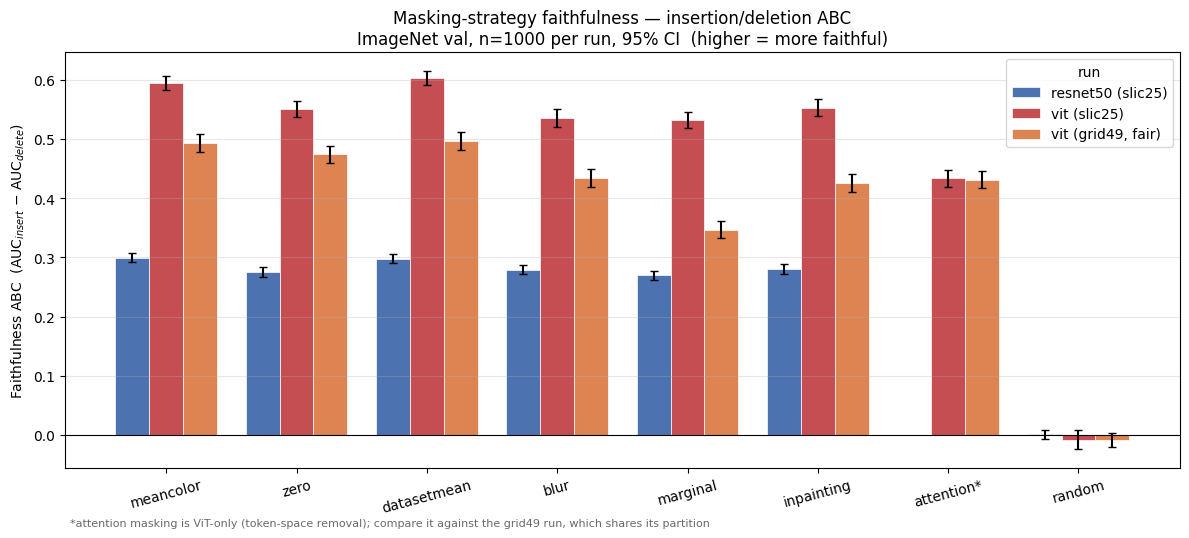

In [10]:
import matplotlib.pyplot as plt

RUN_NAMES = [r[0] for r in RUNS]
METHOD_ORDER = ["meancolor", "zero", "datasetmean", "blur", "marginal",
                "inpainting", "attention", "random"]
PRETTY = {"meancolor": "MeanColor", "zero": "Zero", "datasetmean": "DatasetMean",
          "blur": "Blur", "marginal": "Marginal", "inpainting": "Inpainting",
          "attention": "Attention", "random": "random"}
COLORS = {
    "meancolor": "#1f77b4",    # blue
    "zero": "#ff7f0e",         # orange
    "datasetmean": "#2ca02c",  # green
    "blur": "#e377c2",         # pink
    "marginal": "#9467bd",     # purple
    "inpainting": "#8c564b",   # brown
    "attention": "#17becf",    # cyan
    "random": "#7f7f7f",       # gray
}
RUN_COLORS = {"resnet50": "#4C72B0", "vit": "#C44E52", "vit_grid49": "#DD8452"}
RUN_LABEL = {"resnet50": "resnet50 (slic25)", "vit": "vit (slic25)",
             "vit_grid49": "vit (grid49, fair)"}

methods_present = [m for m in METHOD_ORDER if any(m in abc[k] for k in abc)]
x = np.arange(len(methods_present))
width = 0.26
fig, ax = plt.subplots(figsize=(12, 5.5))

for i, run_name in enumerate(RUN_NAMES):
    means, errs, xs = [], [], []
    for j, m in enumerate(methods_present):
        if m in abc.get(run_name, {}) and abc[run_name][m]:
            means.append(np.mean(abc[run_name][m]))
            errs.append(ci95(abc[run_name][m]))
            xs.append(x[j] + (i - 1) * width)
    ax.bar(xs, means, width, yerr=errs, capsize=3, label=RUN_LABEL[run_name],
           color=RUN_COLORS[run_name], edgecolor="white", linewidth=0.5)

n_img = len(next(iter(abc[RUN_NAMES[0]].values())))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("attention", "attention*") for m in methods_present], rotation=15)
ax.set_ylabel("Faithfulness ABC  (AUC$_{insert}$ − AUC$_{delete}$)")
ax.set_title("Masking-strategy faithfulness — insertion/deletion ABC\n"
             f"ImageNet val, n={n_img} per run, 95% CI  (higher = more faithful)")
ax.legend(title="run", loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.text(0.005, -0.14, "*attention masking is ViT-only (token-space removal); compare it "
                      "against the grid49 run, which shares its partition",
        transform=ax.transAxes, fontsize=8, color="dimgray")
fig.tight_layout()
fig.savefig("data/plot_abc_bars.png", dpi=160, bbox_inches="tight")
plt.show()

### 9.2 · Curves per run — one panel per strategy

Three figures. The third (`vit_grid49`) is the fair one: every panel there shares the
49-tile partition, so `Attention` can be read against its neighbours directly.


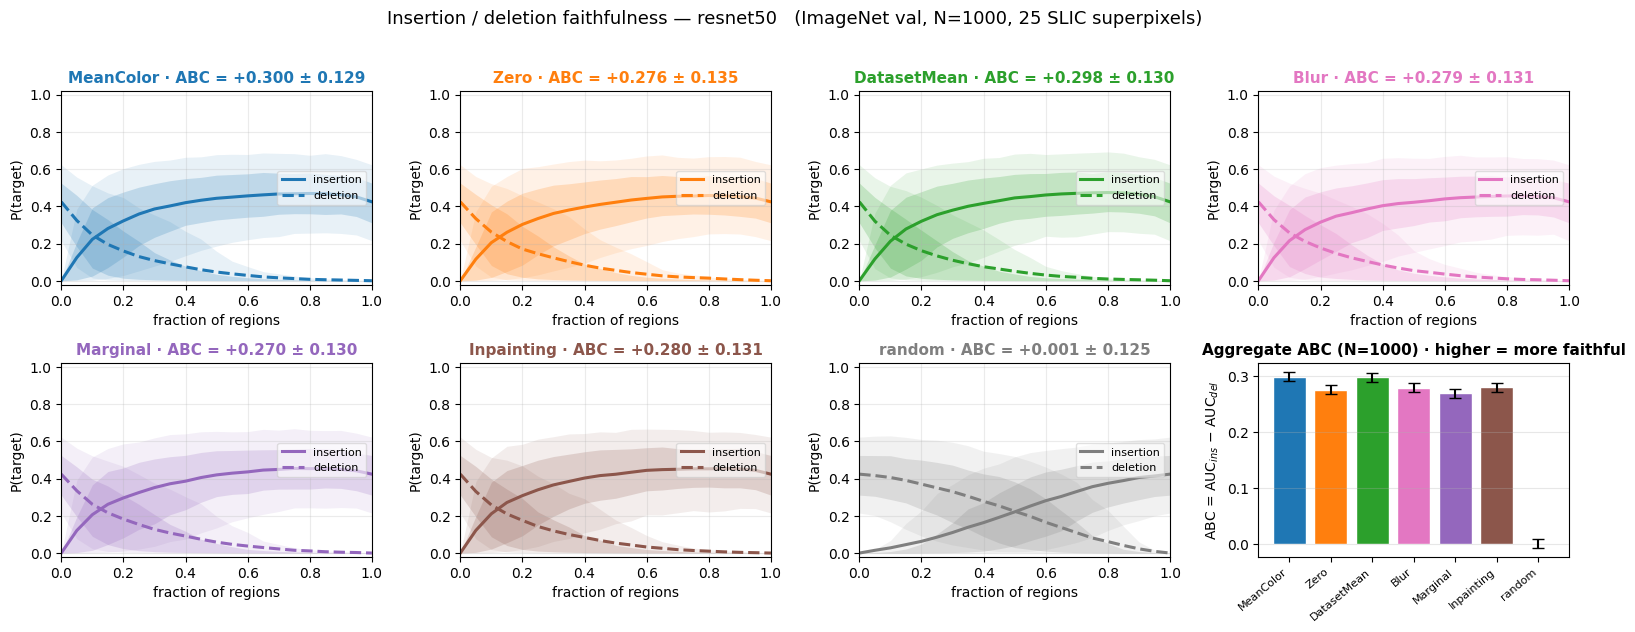

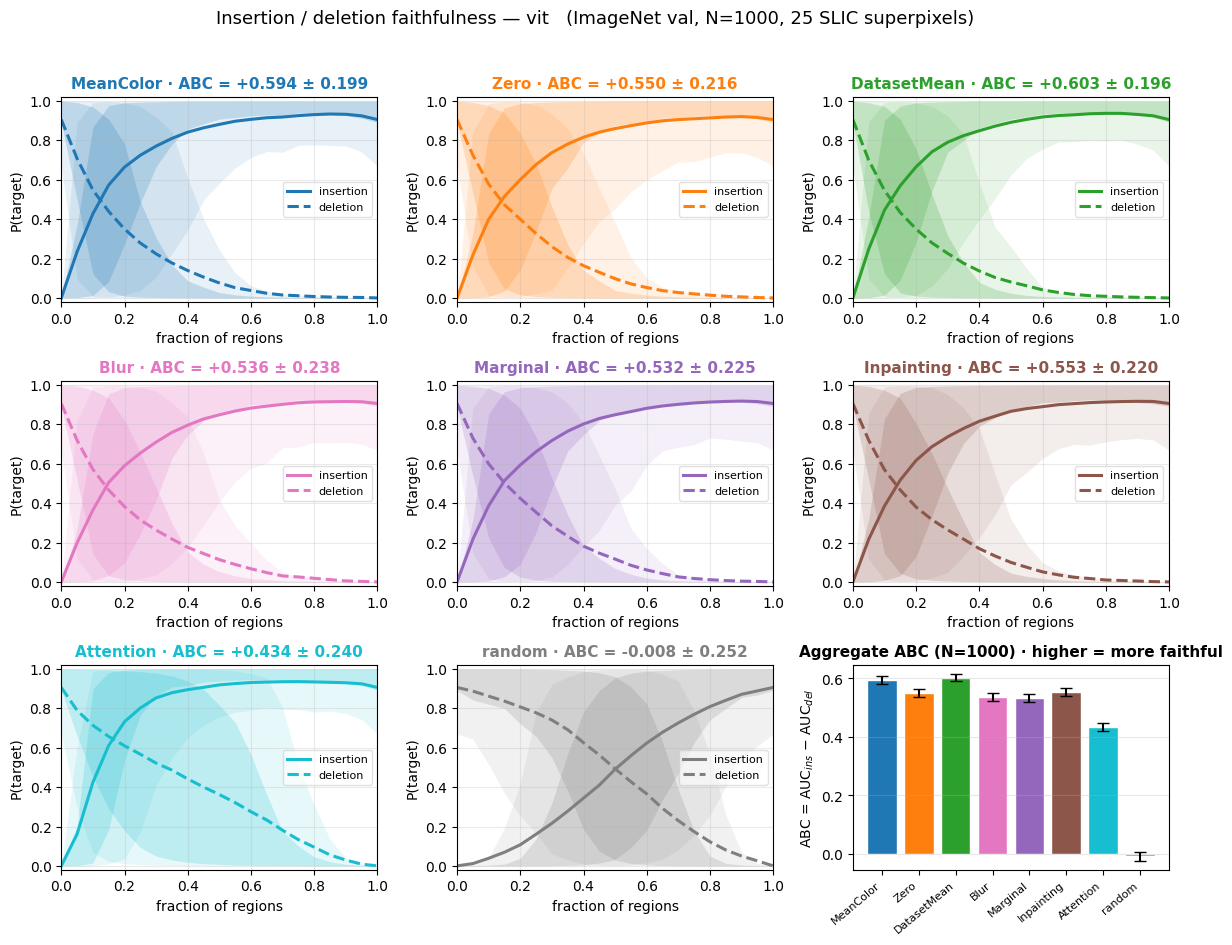

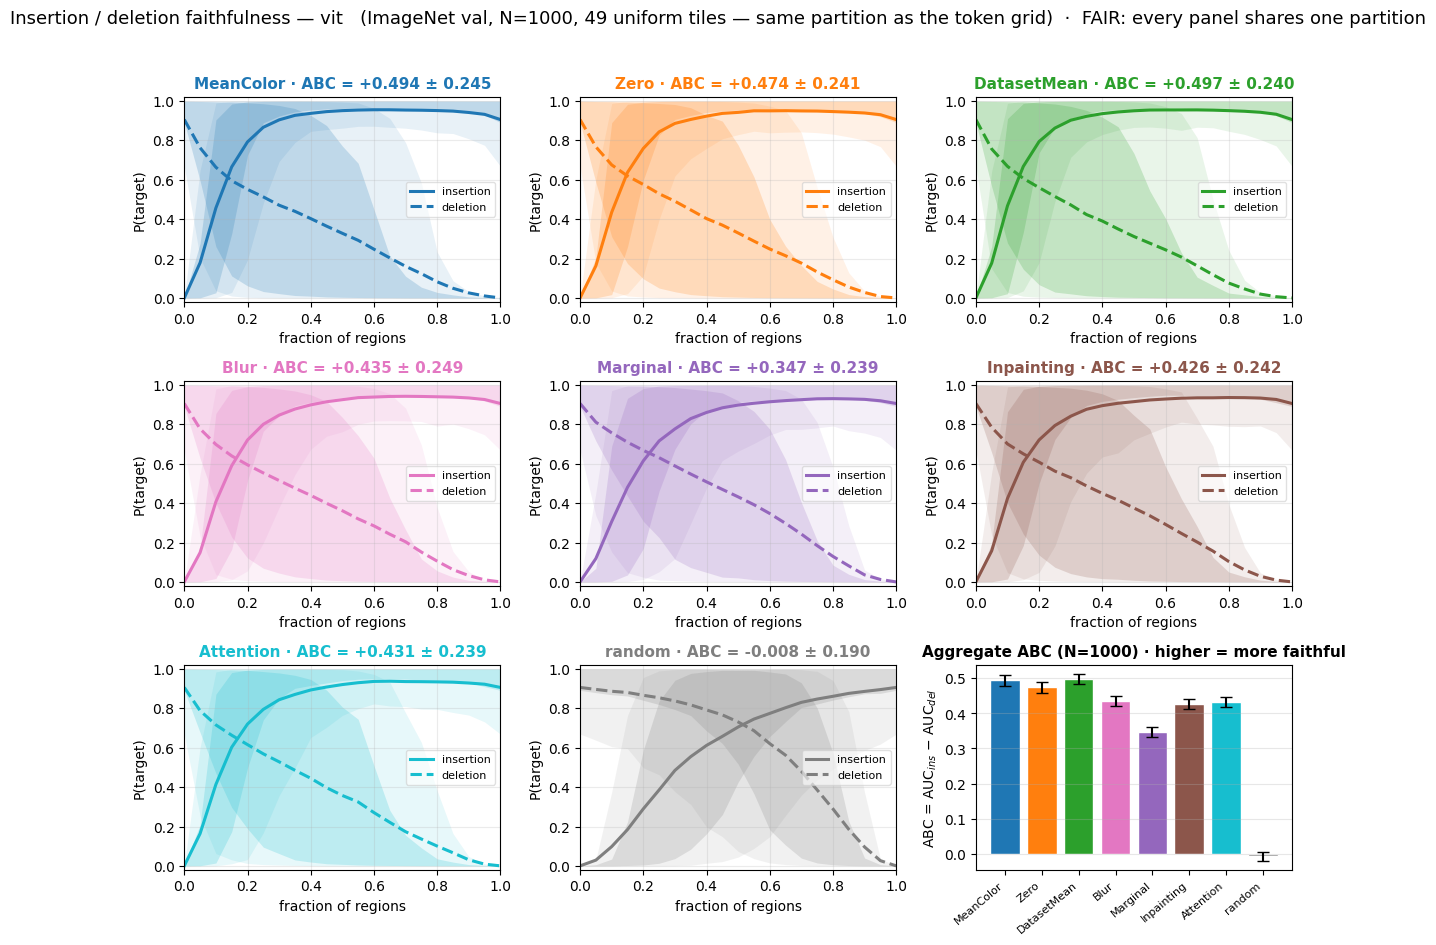

In [11]:
def curve_panel(ax, grid, ins, dele, color, label, abc_mean, abc_std):
    for arr, _ls in ((ins, "-"), (dele, "--")):
        p10, p25, p75, p90 = np.percentile(arr, [10, 25, 75, 90], axis=0)
        ax.fill_between(grid, p10, p90, color=color, alpha=0.10, lw=0)
        ax.fill_between(grid, p25, p75, color=color, alpha=0.20, lw=0)
    ax.plot(grid, ins.mean(0), "-", color=color, lw=2.2, label="insertion")
    ax.plot(grid, dele.mean(0), "--", color=color, lw=2.2, label="deletion")
    ax.set_title(f"{label} · ABC = {abc_mean:+.3f} ± {abc_std:.3f}",
                 fontsize=11, color=color, fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="center right", framealpha=0.6)


PARTITION_LABEL = {"slic25": f"{N_SUPERPIXELS} SLIC superpixels",
                   "grid49": f"{TOKEN_PLAYERS} uniform tiles — same partition as the token grid"}

z = np.load(OUT_NPZ)
grid = z["grid"]

for run_name, model_name, partition in RUNS:
    methods_here = [m for m in METHOD_ORDER if f"{run_name}__{m}__ins" in z.files]
    n_panels = len(methods_here) + 1  # + the aggregate bar panel
    ncols = 4 if n_panels <= 8 else 3
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)

    n_img = len(abc[run_name][methods_here[0]])
    for ax, m in zip(axes, methods_here):
        vals = np.asarray(abc[run_name][m])
        curve_panel(ax, grid, z[f"{run_name}__{m}__ins"], z[f"{run_name}__{m}__del"],
                    COLORS[m], PRETTY[m], vals.mean(), vals.std(ddof=1))
        ax.set_xlabel("fraction of regions")
        ax.set_ylabel("P(target)")

    bax = axes[len(methods_here)]
    means = [np.mean(abc[run_name][m]) for m in methods_here]
    cis = [ci95(abc[run_name][m]) for m in methods_here]
    bax.bar(range(len(methods_here)), means, yerr=cis, capsize=4,
            color=[COLORS[m] for m in methods_here], edgecolor="white")
    bax.set_xticks(range(len(methods_here)))
    bax.set_xticklabels([PRETTY[m] for m in methods_here], rotation=40, ha="right", fontsize=8)
    bax.set_ylabel("ABC = AUC$_{ins}$ − AUC$_{del}$")
    bax.set_title(f"Aggregate ABC (N={n_img}) · higher = more faithful",
                  fontsize=11, fontweight="bold")
    bax.grid(axis="y", alpha=0.3)

    for ax in axes[n_panels:]:
        ax.axis("off")

    fair = "  ·  FAIR: every panel shares one partition" if partition == "grid49" else ""
    fig.suptitle(f"Insertion / deletion faithfulness — {model_name}   "
                 f"(ImageNet val, N={n_img}, {PARTITION_LABEL[partition]}){fair}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(f"data/plot_curves_{run_name}.png", dpi=150, bbox_inches="tight")
    plt.show()